2 (a) To extract features from each image in the training data, SIFT (Scale-invariant feature transform) is employed. To make sure SIFT gives us 128 dimensions per image keypoint, the image is first converted to greyscale.

In [1]:
import numpy as np
import cv2 as cv
 
img = cv.imread('Fruit-Subset/Training/Apple Golden 1/0_100.jpg')
gray= cv.cvtColor(img,cv.COLOR_BGR2GRAY)
 
sift = cv.SIFT_create()
kp = sift.detect(gray,None)
 
img=cv.drawKeypoints(gray,kp,img)
 
cv.imwrite('sift_keypoints.jpg',img)

True

The following image results from taking the 128 dimensional keypoints of the first golden apple image.

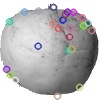

2 (b) A keypoints dataset KP is created below such that it contains all the keypoints from all the training images.

In [2]:
import os

def extract_all_sift_features(image_folder):
    sift = cv.SIFT_create()
    all_features = []
    
    for root, dirs, files in os.walk(image_folder):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(root, file)
                img = cv.imread(img_path)
                gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                kp, des = sift.detectAndCompute(gray, None)
                if des is not None:
                    all_features.append(des)
    
    return all_features

image_folder = 'Fruit-Subset/Training'
features = extract_all_sift_features(image_folder)

In [3]:
features_array = np.vstack(features) #KP: Stack all feature descriptors into a single array
print("Total SIFT features extracted:", features_array.shape[0])
print("Feature dimension:", features_array.shape[1])
print("Sample SIFT feature vector:", features_array[0])

Total SIFT features extracted: 179596
Feature dimension: 128
Sample SIFT feature vector: [  1.   0.   0.   0.   8.  53.  10.   0. 159.  85.   0.   0.  15.  29.
   1.   2. 159. 113.   0.   0.   0.   0.   0.   0.   8.   5.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   3.  39.  37.   4.   0. 159.  31.
   0.   0.  55.  32.   1.   7. 159.  90.   0.   0.   0.   0.   0.  10.
  26.   6.   0.   0.   0.   0.   0.   0.   0.   0.   0.   8.  56.   9.
   0.   0. 125.   3.   0.   2.  32.  19.   5.  67. 159.  12.   0.   0.
   0.   0.   1. 121.  23.   1.   0.   0.   0.   0.   0.   5.   0.   0.
   0.   0.  31.  29.   3.   0. 153.   9.   0.   0.  13.  11.   1.  39.
 159.  20.   0.   0.   0.   0.   0.  45.   2.   0.   0.   0.   0.   0.
   0.   1.]


2 (c) K means clustering such that K = 100 on KP is performed

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=100, random_state=0, n_init="auto").fit(features_array)

# Access results
labels = kmeans.labels_          # Cluster labels for each sample
centers = kmeans.cluster_centers_ # Coordinates of cluster centers

2 (d) The K-mean clusters are then used to construct a 100-D vector for each image such that each of the dimensions corresponds to the number of keypoints with each indexed (0-99) cluster. For an image A, if 20 keypoints exist in cluster 1, 10 keypoints exist in cluster 2, and none exist in other clusters, the vector represent Image A takes on the form:

$v = \left(20,10,0,0,0,...,0,0\right)$

In [ ]:
'''
Constructing 100-dimension vector for each image representing the keypoints present in that image
such that the i-th dimension of the vector represents the number of keypoints in that image that belong to the i-th cluster.

Recall that the features_array has 128 dimensions for each keypoint, and the kmeans variable contains the cluster centers 
and labels for each keypoint. We can use the labels to count how many keypoints from each image belong to each cluster to
construct the 100-dimensional vectors.

'''
image_vectors = []  # List to hold the 100-dimensional vectors for each image
for image in features: #Iterate though each row in the features, where each row corresponds to a keypoint descriptor
    #print(image.shape) #This will print the shape of each image keypoint descriptor, which should be (keypoints, 128) since SIFT features are 128-dimensional.
    image_vector = np.zeros(100)  # Initialize a 100-dimensional vector for the image
    cluster_label = kmeans.predict(image)  # Get the cluster label for the keypoints
    image_vector[cluster_label] += 1  # Increment the count for the corresponding cluster
    image_vectors.append(image_vector)  # Add the image vector to the list
    #print(image_vector.shape)  # This will print the 100-dimensional vector for each image

image_vectors = np.array(image_vectors)  # Convert the list of image vectors to a NumPy array for easier handling

2 (e) Now that we have defined our 100-dimensional dataset D (with image_vectors) we can smoothly proceed to PCA

2 (f) We now reduce the dataset D to 2 dimensions with PCA

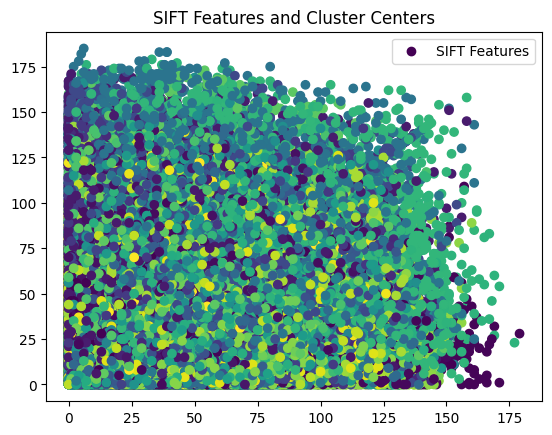

In [8]:
import matplotlib.pyplot as plt
plt.scatter(features_array[:, 0], features_array[:, 1], c=kmeans.labels_, label='SIFT Features')
plt.title('SIFT Features and Cluster Centers')
plt.legend()
plt.show()